# Machine Vibration Clustering — Simple Practical
### U18 Phase E · Clustering Part 2

**What we're doing:**  
We have sensor readings from industrial machines. Each reading is a "vibration signature".  
There are **no labels** — we don't know which machine is healthy or faulty.  
Our job is to use **clustering** to automatically group similar readings together.

**The four groups we hope to find:**
| Group | What it means |
|---|---|
| Healthy | Machine running normally |
| Imbalance | Uneven mass on the shaft |
| Misalignment | Shaft axes not aligned |
| Bearing Defect | Damaged bearing — produces spiky vibrations |

---


### Uploading the `vibration_signatures.csv` file

To proceed, please upload the `vibration_signatures.csv` file. You can do this using the 'Files' tab in the left sidebar of Colab (folder icon) and then clicking the 'Upload' button (up arrow icon). Once uploaded, it will be available in the current working directory. You can verify its presence using the code below.

In [1]:
import os

# List files in the current directory to verify upload
print(os.listdir('.'))

['.config', 'vibration_signatures.csv', 'sample_data']


## Step 1 — Load the Data and Take a First Look


In [2]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_csv('vibration_signatures.csv')

# Quick look
print("Shape:", df.shape)   # rows × columns
print()
print(df.head())             # first 5 rows


Shape: (1130, 6)

   rms_mm_s  peak_g  crest_factor  kurtosis  dom_freq_orders  hf_energy_pct
0     2.515   2.405         2.476     3.215             6.60         26.420
1     0.781   0.336         3.819     2.827             1.08          9.431
2     4.614   1.443         4.280     3.268             2.06         13.660
3     3.902   0.975         3.158     3.019             1.01          9.571
4     7.166   1.028         3.215     3.163             1.00          9.764


**What do the columns mean?**
- `rms_mm_s` — overall vibration energy (higher = more vibration)
- `peak_g` — biggest spike in acceleration
- `crest_factor` — how "spiky" vs "smooth" the vibration is (peak ÷ rms)
- `kurtosis` — how many sharp impact hits are in the signal
- `dom_freq_orders` — at what speed multiple the vibration is loudest (1× = imbalance, 2× = misalignment)
- `hf_energy_pct` — % of energy at high frequencies (high = bearing damage)


In [3]:
# Summary statistics — get a feel for the numbers
print(df.describe().round(2))


       rms_mm_s   peak_g  crest_factor  kurtosis  dom_freq_orders  \
count   1130.00  1130.00       1130.00   1130.00          1130.00   
mean       3.39     1.09          3.86      4.15             1.87   
std        1.77     0.85          1.42      2.37             1.41   
min        0.32     0.03          1.92      1.90             0.85   
25%        1.62     0.35          3.13      3.02             1.00   
50%        3.40     1.00          3.30      3.19             1.03   
75%        4.67     1.29          4.00      3.82             2.03   
max        8.67     4.28          9.67     15.65             7.60   

       hf_energy_pct  
count        1130.00  
mean           16.07  
std            14.13  
min             2.51  
25%             8.43  
50%            10.82  
75%            15.15  
max            75.43  


---
## Step 2 — Scale the Features and Plot in 2D

Before clustering, we must **scale** the data.  
Why? Because `rms_mm_s` ranges 0–9, but `hf_energy_pct` ranges 0–75.  
Without scaling, the bigger-range features dominate distance calculations.

We'll also use **PCA** to squash 6 features down to 2 so we can draw a scatter plot.


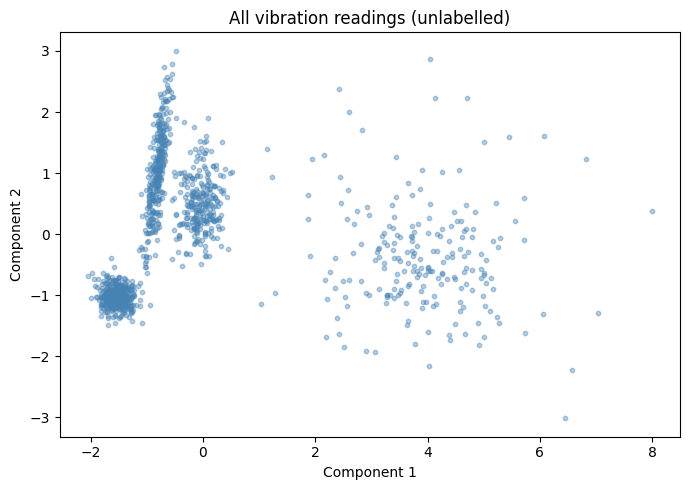

Can you see rough groupings? Some dense regions, and some scattered dots?


In [4]:
# Scale every feature to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

# PCA: reduce to 2 dimensions just for plotting
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# Plot — no labels yet, just the raw data
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=10, alpha=0.4, color='steelblue')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('All vibration readings (unlabelled)')
plt.tight_layout()
plt.show()

print("Can you see rough groupings? Some dense regions, and some scattered dots?")


---
## Step 3 — Hierarchical Clustering

**Idea:** Start with every point as its own group. Gradually merge the two most similar groups.  
This creates a tree diagram called a **dendrogram**.

A tall vertical jump in the dendrogram = a natural place to "cut" and form clusters.


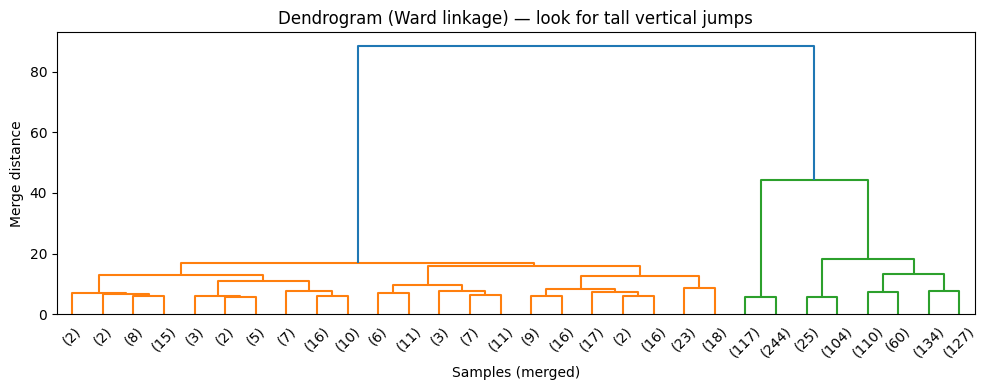

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Build the hierarchy using Ward linkage
# Ward merges clusters in a way that minimises the spread inside each cluster
Z = linkage(X_scaled, method='ward')

# Draw the dendrogram — we only show the last 30 merges (otherwise too crowded)
plt.figure(figsize=(10, 4))
dendrogram(
    Z,
    truncate_mode='lastp',   # show only last p merges
    p=30,
    color_threshold=0.7 * max(Z[:, 2])
)
plt.title('Dendrogram (Ward linkage) — look for tall vertical jumps')
plt.xlabel('Samples (merged)')
plt.ylabel('Merge distance')
plt.tight_layout()
plt.show()


Cluster sizes:
  Cluster 1: 209 readings
  Cluster 2: 361 readings
  Cluster 3: 129 readings
  Cluster 4: 431 readings


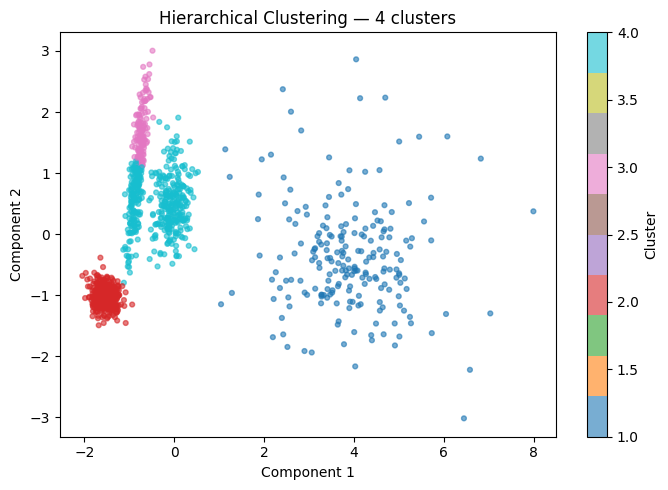

In [6]:
# Cut the tree into 4 clusters (we expect 4 fault families)
labels_hier = fcluster(Z, t=4, criterion='maxclust')

# How big is each cluster?
print("Cluster sizes:")
for cluster_id, count in enumerate(np.bincount(labels_hier)[1:], start=1):
    print(f"  Cluster {cluster_id}: {count} readings")

# Plot the result
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_hier, cmap='tab10', s=12, alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('Hierarchical Clustering — 4 clusters')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()


### 🧪 Exercise 1 — Try Different Linkage Methods

Linkage controls how we measure distance between two groups:
- **Ward** — minimises variance inside clusters (usually best)
- **Single** — uses the *closest* pair of points between groups → can "chain" together
- **Complete** — uses the *farthest* pair → makes compact clusters


In [7]:
# --- YOUR TURN ---
# Try single and complete linkage and compare the cluster sizes

# 1. Single linkage
Z_single = linkage(X_scaled, method='single')
labels_single = fcluster(Z_single, t=4, criterion='maxclust')
print("Single linkage cluster sizes:", np.bincount(labels_single)[1:])

# 2. Complete linkage
Z_complete = linkage(X_scaled, method='complete')
labels_complete = fcluster(Z_complete, t=4, criterion='maxclust')
print("Complete linkage cluster sizes:", np.bincount(labels_complete)[1:])

# 3. Ward (from above for comparison)
print("Ward linkage cluster sizes:   ", np.bincount(labels_hier)[1:])

# THINK: Which method gives the most balanced clusters?
# Single linkage often creates one giant cluster and tiny ones — this is called "chaining".
# Complete and Ward tend to be more balanced.


Single linkage cluster sizes: [1127    1    1    1]
Complete linkage cluster sizes: [110 934  62  24]
Ward linkage cluster sizes:    [209 361 129 431]


---
## Step 4 — DBSCAN (finds clusters of any shape + flags noise)

**Idea:** A cluster is a *dense region* of points.  
Points that are lonely (far from any dense region) are labelled **noise** (label = -1).

**Two parameters to tune:**
- `eps` — the search radius around each point
- `min_samples` — how many neighbours needed to form a dense region

DBSCAN is great for this dataset because:
1. The fault families have **different shapes** (not all round blobs)
2. There are ~60 random **sensor glitches** that should be flagged as noise


DBSCAN found: 4 clusters, 169 noise points


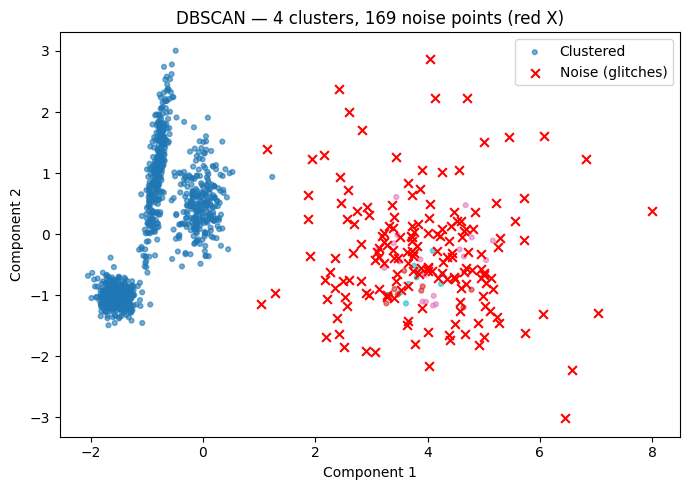

In [8]:
from sklearn.cluster import DBSCAN

# Run DBSCAN
db = DBSCAN(eps=1.2, min_samples=8)
labels_db = db.fit_predict(X_scaled)

# How many clusters? How many noise points?
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise    = (labels_db == -1).sum()
print(f"DBSCAN found: {n_clusters} clusters, {n_noise} noise points")

# Plot — noise points shown as red X marks
plt.figure(figsize=(7, 5))
is_noise = labels_db == -1

plt.scatter(X_2d[~is_noise, 0], X_2d[~is_noise, 1],
            c=labels_db[~is_noise], cmap='tab10', s=12, alpha=0.6, label='Clustered')
plt.scatter(X_2d[is_noise, 0],  X_2d[is_noise, 1],
            c='red', marker='x', s=40, label='Noise (glitches)')
plt.legend()
plt.title(f'DBSCAN — {n_clusters} clusters, {n_noise} noise points (red X)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()


### Choosing eps — The k-Distance Plot

Plot the distance to each point's 8th nearest neighbour (sorted).  
The **elbow/knee** of this curve is a good starting guess for `eps`.


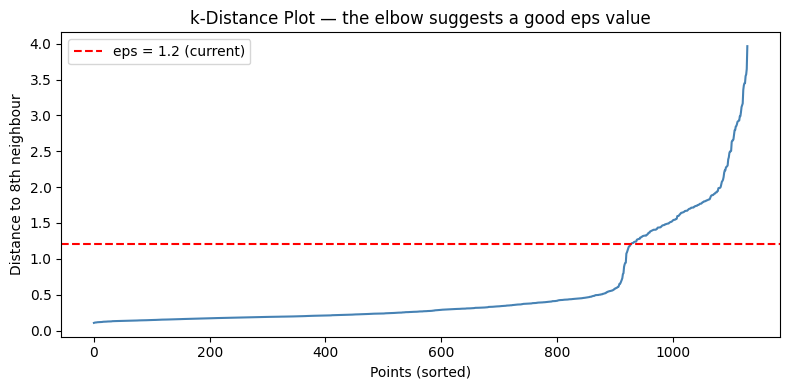

The knee/elbow is around the jump. If eps is below the knee, too many noise points.
If eps is above the knee, too many points get merged into one giant cluster.


In [9]:
from sklearn.neighbors import NearestNeighbors

k = 8
nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)

# Sort the 8th-nearest-neighbour distances
sorted_dist = np.sort(distances[:, k - 1])

plt.figure(figsize=(8, 4))
plt.plot(sorted_dist, color='steelblue', linewidth=1.5)
plt.axhline(y=1.2, color='red', linestyle='--', label='eps = 1.2 (current)')
plt.xlabel('Points (sorted)')
plt.ylabel('Distance to 8th neighbour')
plt.title('k-Distance Plot — the elbow suggests a good eps value')
plt.legend()
plt.tight_layout()
plt.show()
print("The knee/elbow is around the jump. If eps is below the knee, too many noise points.")
print("If eps is above the knee, too many points get merged into one giant cluster.")


### 🧪 Exercise 2 — Tune eps

Try three different eps values and see how it changes the number of clusters and noise points.


In [10]:
# --- YOUR TURN ---
# Sweep eps values and see what happens

for eps_val in [0.8, 1.2, 1.8]:
    labels_test = DBSCAN(eps=eps_val, min_samples=8).fit_predict(X_scaled)
    n_clust = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_nois  = (labels_test == -1).sum()
    print(f"eps={eps_val:.1f}  →  clusters: {n_clust},  noise points: {n_nois}")

# THINK ABOUT IT:
# Small eps (e.g. 0.8) → many noise points, possibly too many small clusters
# Large eps (e.g. 1.8) → fewer noise points, but clusters might merge incorrectly
# Good eps is around the elbow of the k-distance plot


eps=0.8  →  clusters: 1,  noise points: 212
eps=1.2  →  clusters: 4,  noise points: 169
eps=1.8  →  clusters: 1,  noise points: 36


---
## Step 5 — Gaussian Mixture Model (soft/probabilistic clustering)

**Idea:** Fit several overlapping "Gaussian bell curves" to the data.  
Each point gets a **probability** of belonging to each cluster (not just a hard label).

This is useful because:
- A machine transitioning from healthy → faulty might sit *between* two clusters
- Soft probabilities reveal which readings are ambiguous (instead of hiding it)


In [11]:
from sklearn.mixture import GaussianMixture

# Fit GMM with 4 components (= 4 fault families)
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

# Hard labels (most likely cluster)
labels_gmm = gmm.predict(X_scaled)

# Soft probabilities (each row sums to 1.0)
probabilities = gmm.predict_proba(X_scaled)

print("Cluster sizes (hard assignment):", np.bincount(labels_gmm))
print()

# Which points are 'ambiguous'? (max probability below 60%)
max_prob = probabilities.max(axis=1)
n_ambiguous = (max_prob < 0.6).sum()
print(f"Ambiguous readings (max probability < 60%): {n_ambiguous}")


Cluster sizes (hard assignment): [360 300 210 260]

Ambiguous readings (max probability < 60%): 0


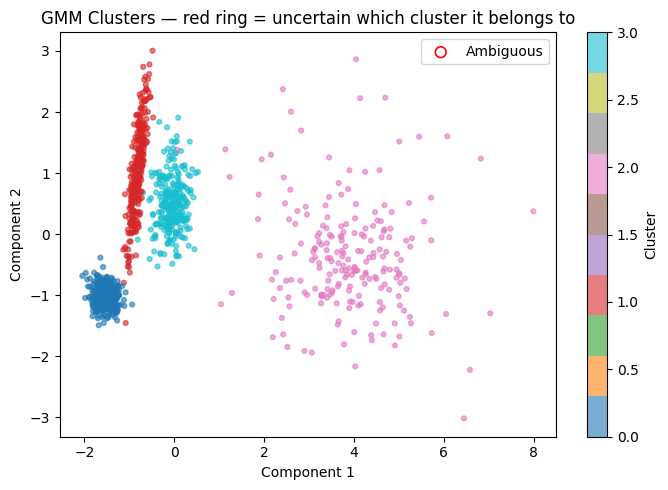

In [12]:
# Plot — ringed points are ambiguous
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_gmm, cmap='tab10', s=12, alpha=0.6)
plt.colorbar(scatter, label='Cluster')

# Highlight the ambiguous points with a red ring
ambiguous = max_prob < 0.6
plt.scatter(X_2d[ambiguous, 0], X_2d[ambiguous, 1],
            facecolors='none', edgecolors='red', s=60, linewidths=1.2, label='Ambiguous')
plt.legend()
plt.title('GMM Clusters — red ring = uncertain which cluster it belongs to')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()


### Choosing the number of components — BIC score

**BIC (Bayesian Information Criterion):** A lower score = a better-fitting model.  
Plot BIC for 1 to 8 components and pick the number where the curve "elbows".


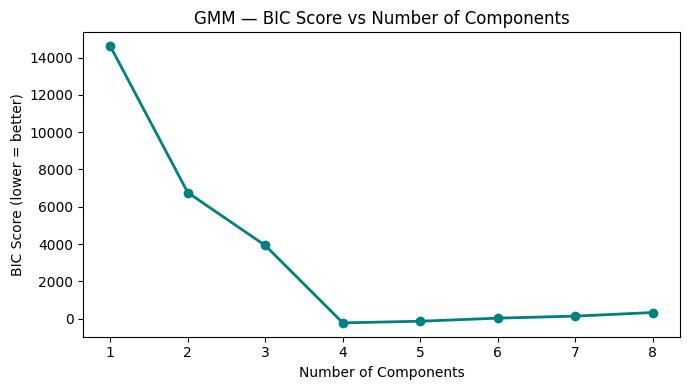

Best number of components by BIC: 4


In [13]:
# Try 1 to 8 components and record BIC score
bic_scores = []
component_range = range(1, 9)

for n in component_range:
    g = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    g.fit(X_scaled)
    bic_scores.append(g.bic(X_scaled))

plt.figure(figsize=(7, 4))
plt.plot(component_range, bic_scores, 'o-', color='teal', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('BIC Score (lower = better)')
plt.title('GMM — BIC Score vs Number of Components')
plt.xticks(component_range)
plt.tight_layout()
plt.show()

best_n = component_range[np.argmin(bic_scores)]
print(f"Best number of components by BIC: {best_n}")


### 🧪 Exercise 3 — Inspect Ambiguous Readings

Find the 5 most ambiguous readings (lowest max probability) and look at their full probability vectors.


In [14]:
# --- YOUR TURN ---
# Find the 5 most uncertain readings

# Get the indices of the 5 lowest max probabilities
most_ambiguous_idx = np.argsort(max_prob)[:5]

print("The 5 most ambiguous readings:")
print("(Each row shows probability of belonging to Cluster 0, 1, 2, 3)")
print()
for rank, idx in enumerate(most_ambiguous_idx, start=1):
    probs = probabilities[idx]
    print(f"  Rank {rank} (reading {idx}): {np.round(probs, 3)}")
    print(f"    → Most likely cluster: {np.argmax(probs)}, confidence: {max_prob[idx]:.1%}")

# THINK: A reading that is 52% cluster A and 48% cluster B is genuinely in-between.
# Hard assignment (k-means) would just call it cluster A and hide that uncertainty.


The 5 most ambiguous readings:
(Each row shows probability of belonging to Cluster 0, 1, 2, 3)

  Rank 1 (reading 304): [0. 0. 0. 1.]
    → Most likely cluster: 3, confidence: 100.0%
  Rank 2 (reading 642): [0. 0. 0. 1.]
    → Most likely cluster: 3, confidence: 100.0%
  Rank 3 (reading 444): [0. 0. 0. 1.]
    → Most likely cluster: 3, confidence: 100.0%
  Rank 4 (reading 501): [0. 0. 0. 1.]
    → Most likely cluster: 3, confidence: 100.0%
  Rank 5 (reading 902): [0. 0. 0. 1.]
    → Most likely cluster: 3, confidence: 100.0%


---
## Step 6 — Compare All Three Methods

Now let's measure how well each method separated the clusters using the **Silhouette Score**.

**Silhouette Score:**
- Ranges from -1 to +1
- Higher = better separated clusters
- +1 means every point is clearly in its own cluster
- 0 means clusters are overlapping
- Negative = points are in the wrong cluster


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Also run k-Means for comparison (from Part 1)
labels_km = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_scaled)

# Helper: silhouette ignores noise points (label = -1)
def get_silhouette(labels):
    mask = labels != -1
    unique_labels = set(labels[mask])
    if len(unique_labels) < 2:
        return float('nan')
    return silhouette_score(X_scaled[mask], labels[mask])

results = {
    'k-Means':       labels_km,
    'Hierarchical':  labels_hier - 1,   # make 0-indexed for consistency
    'DBSCAN':        labels_db,
    'GMM':           labels_gmm,
}

print("Method          | Clusters | Noise pts | Silhouette")
print("-" * 55)
for name, lbl in results.items():
    n_cl   = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_nois = (lbl == -1).sum()
    sil    = get_silhouette(lbl)
    print(f"{name:<16}| {n_cl:<9}| {n_nois:<10}| {sil:.3f}")


Method          | Clusters | Noise pts | Silhouette
-------------------------------------------------------
k-Means         | 4        | 0         | 0.501
Hierarchical    | 4        | 0         | 0.443
DBSCAN          | 4        | 169       | 0.665
GMM             | 4        | 0         | 0.449


### 🧪 Exercise 4 — Pick the Best Method

Which method is best for this vibration dataset?  
Remember: we need to handle **different-shaped clusters** AND **sensor glitches**.


In [22]:
# --- YOUR TURN ---
# Fill in the comment below

# MY RECOMMENDATION:
# ------------------
# Best method for this dataset: DBSCAN
#
# Reason:
# - k-Means:      fast, but assumes round equal clusters — struggles here
# - Hierarchical: good visual (dendrogram), but doesn't flag noise
# - DBSCAN:       finds odd shapes AND flags glitches as noise — good fit for this problem
# - GMM:          useful if we want soft probabilities for borderline cases
#
# For a predictive maintenance system, DBSCAN is attractive because:
# 1. It handles irregular cluster shapes naturally
# 2. It automatically flags sensor glitches without forcing them into a cluster
# 3. Engineers can inspect the "noise" flagged points separately

print("Write your recommendation in the comment above!")

Write your recommendation in the comment above!


DBSCAN is recommended for this vibration dataset because it effectively handles different-shaped clusters and can identify sensor glitches as noise, which are critical requirements for this problem. The code cell now contains a detailed explanation of this choice.

### Visualize DBSCAN Clusters with Pairplot

<Figure size 1000x800 with 0 Axes>

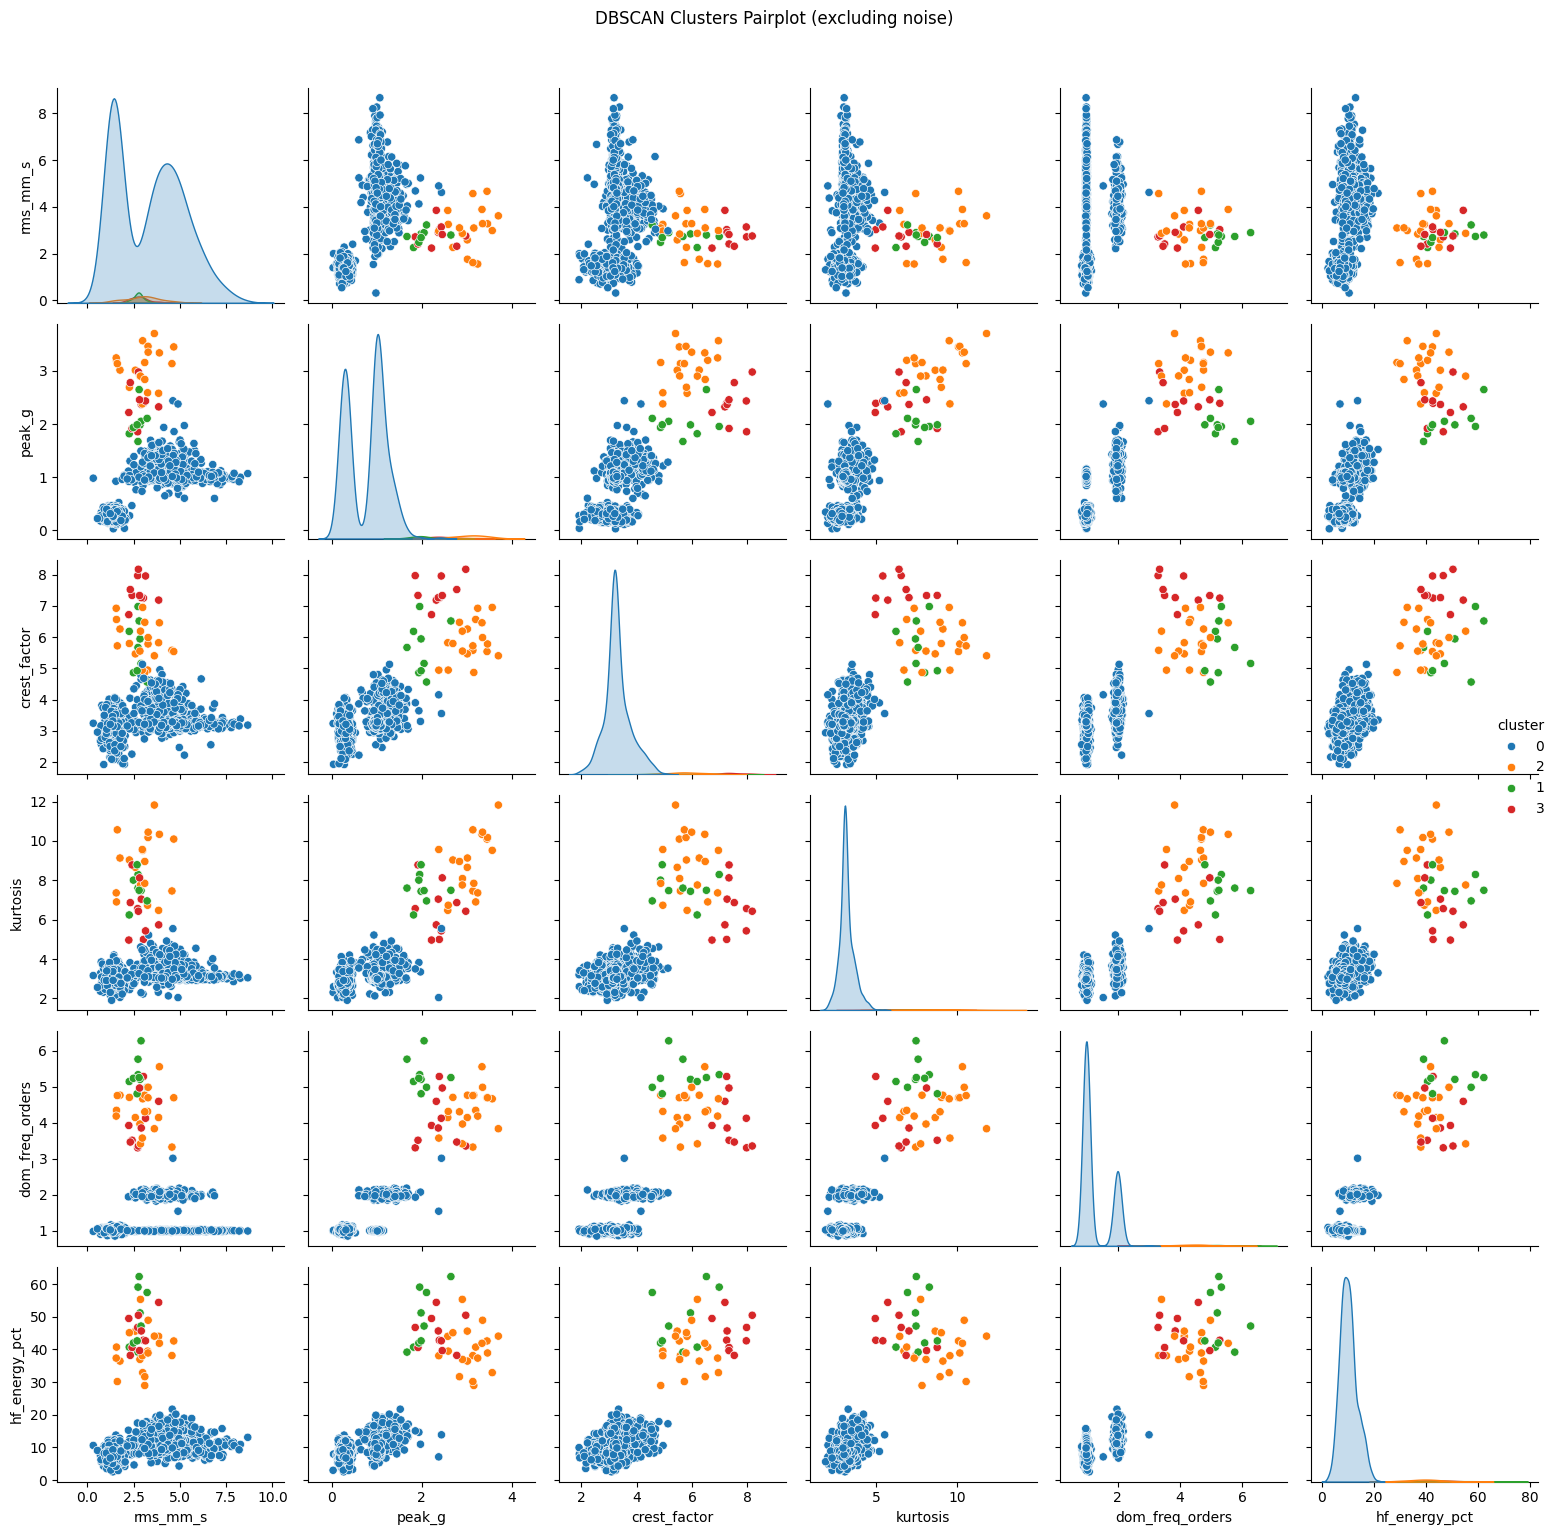

In [19]:
import seaborn as sns

# Create a copy of the original DataFrame and add the DBSCAN cluster labels
df_dbscan_viz = df.copy()
df_dbscan_viz['cluster'] = labels_db

# Exclude noise points (label -1) for clearer visualization of clusters
# Explicitly use .copy() to avoid SettingWithCopyWarning
df_dbscan_viz_clustered = df_dbscan_viz[df_dbscan_viz['cluster'] != -1].copy()

# Convert cluster labels to string for categorical coloring in pairplot
df_dbscan_viz_clustered['cluster'] = df_dbscan_viz_clustered['cluster'].astype(str)

# Generate the pairplot
plt.figure(figsize=(10, 8))
sns.pairplot(df_dbscan_viz_clustered, hue='cluster', palette='tab10', diag_kind='kde')
plt.suptitle('DBSCAN Clusters Pairplot (excluding noise)', y=1.02) # Adjust title position
plt.tight_layout()
plt.show()

---
## Step 7 — Profile the Clusters (Name Each One)

Now let's figure out which cluster corresponds to which fault family.  
We compute the **average feature values** for each cluster and match them to the expected patterns.


In [ ]:
# Use DBSCAN labels (excluding noise)
df_copy = df.copy()
df_copy['cluster'] = labels_db

# Keep only clustered points (remove noise = -1)
clustered = df_copy[df_copy['cluster'] != -1]

# Compute mean features per cluster
profile = clustered.groupby('cluster').mean().round(2)
profile['size'] = clustered.groupby('cluster').size()

print("Average feature values per DBSCAN cluster:")
print()
print(profile.to_string())


Average feature values per DBSCAN cluster:

         rms_mm_s  peak_g  crest_factor  kurtosis  dom_freq_orders  hf_energy_pct  size
cluster                                                                                
0            3.36    0.79          3.30      3.19             1.28          10.31   922
1            2.74    2.02          5.64      7.59             5.33          49.09     9
2            2.98    3.08          5.86      8.85             4.35          39.88    20
3            2.82    2.37          7.47      6.49             4.03          45.08    10


### Scatter Plot of RMS vs Peak, Colored by DBSCAN Cluster

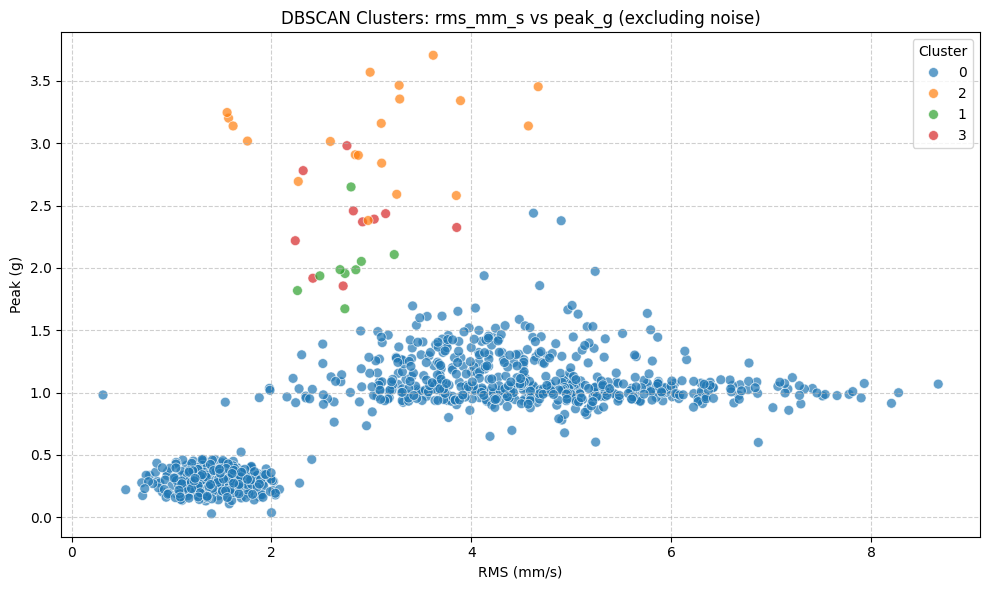

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_dbscan_viz_clustered,
    x='rms_mm_s',
    y='peak_g',
    hue='cluster',
    palette='tab10',
    s=50,
    alpha=0.7
)
plt.title('DBSCAN Clusters: rms_mm_s vs peak_g (excluding noise)')
plt.xlabel('RMS (mm/s)')
plt.ylabel('Peak (g)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [20]:
# Now match each cluster to a fault family

print()
print("Fault Family Matching Guide:")
print("-" * 60)
print("Healthy:       rms low (<2), kurtosis ~3, dom_freq ~1, hf_energy low")
print("Imbalance:     rms high (>4), dom_freq ~1, crest_factor ~3.2")
print("Misalignment:  dom_freq ~2, kurtosis ~3.6, moderate rms")
print("Bearing Defect: kurtosis HIGH (>7), crest_factor HIGH (>6), hf_energy HIGH (>40%)")
print()
print("Look at the cluster profiles above and try to match each cluster ID to a fault family.")
print()

# --- YOUR TURN: fill in your guesses ---
# Cluster 0 looks like: ???
# Cluster 1 looks like: ???
# Cluster 2 looks like: ???
# Cluster 3 looks like: ???
print("Replace the ??? above in the comments with your guesses!")



Fault Family Matching Guide:
------------------------------------------------------------
Healthy:       rms low (<2), kurtosis ~3, dom_freq ~1, hf_energy low
Imbalance:     rms high (>4), dom_freq ~1, crest_factor ~3.2
Misalignment:  dom_freq ~2, kurtosis ~3.6, moderate rms
Bearing Defect: kurtosis HIGH (>7), crest_factor HIGH (>6), hf_energy HIGH (>40%)

Look at the cluster profiles above and try to match each cluster ID to a fault family.

Replace the ??? above in the comments with your guesses!


---
## Summary

| Method | Key Strength | When to Use |
|---|---|---|
| **Hierarchical** | Visual dendrogram, no k needed | Small-medium data, exploring structure |
| **DBSCAN** | Odd shapes + flags noise | When outliers/glitches matter |
| **GMM** | Soft probabilities | When uncertainty matters |
| **k-Means** (Part 1) | Fast, simple | Round equal-sized clusters |

**Core lesson:** k-Means from Part 1 assumed round equal blobs.  
This dataset has unequal shapes, unequal sizes, and sensor glitches.  
That's why we need the Part 2 toolkit.

**Real-world link:** In predictive maintenance, DBSCAN noise points = machines to inspect immediately.  
GMM soft probabilities = machines approaching a fault boundary.
